# Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

In [2]:
# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "#f9f9f9"})

In [3]:
# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv("data\sh\shanghai.csv", parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)
print(f"Shape: {df.shape}")
print(df.head())

Shape: (31482, 17)
                 time  wea  tem  hum  win  dir  winclass  tembody  year  \
0 2017-01-01 00:00:00   11   10   93    7    4         5        9  2017   
1 2017-01-01 01:00:00   11   10   93    7    4         5        8  2017   
2 2017-01-01 02:00:00   23    9   93    7    4         5        8  2017   
3 2017-01-01 03:00:00   23    9   93    7    1         5        7  2017   
4 2017-01-01 04:00:00   23    9   93   13    1         6        7  2017   

   month  day  hour  day_of_year  week_of_year  day_of_week  is_workday  \
0      1    1     0            1            52            6           0   
1      1    1     1            1            52            6           0   
2      1    1     2            1            52            6           0   
3      1    1     3            1            52            6           0   
4      1    1     4            1            52            6           0   

      load  
0  14635.0  
1  13644.8  
2  12877.2  
3  12530.0  
4  12170.0  


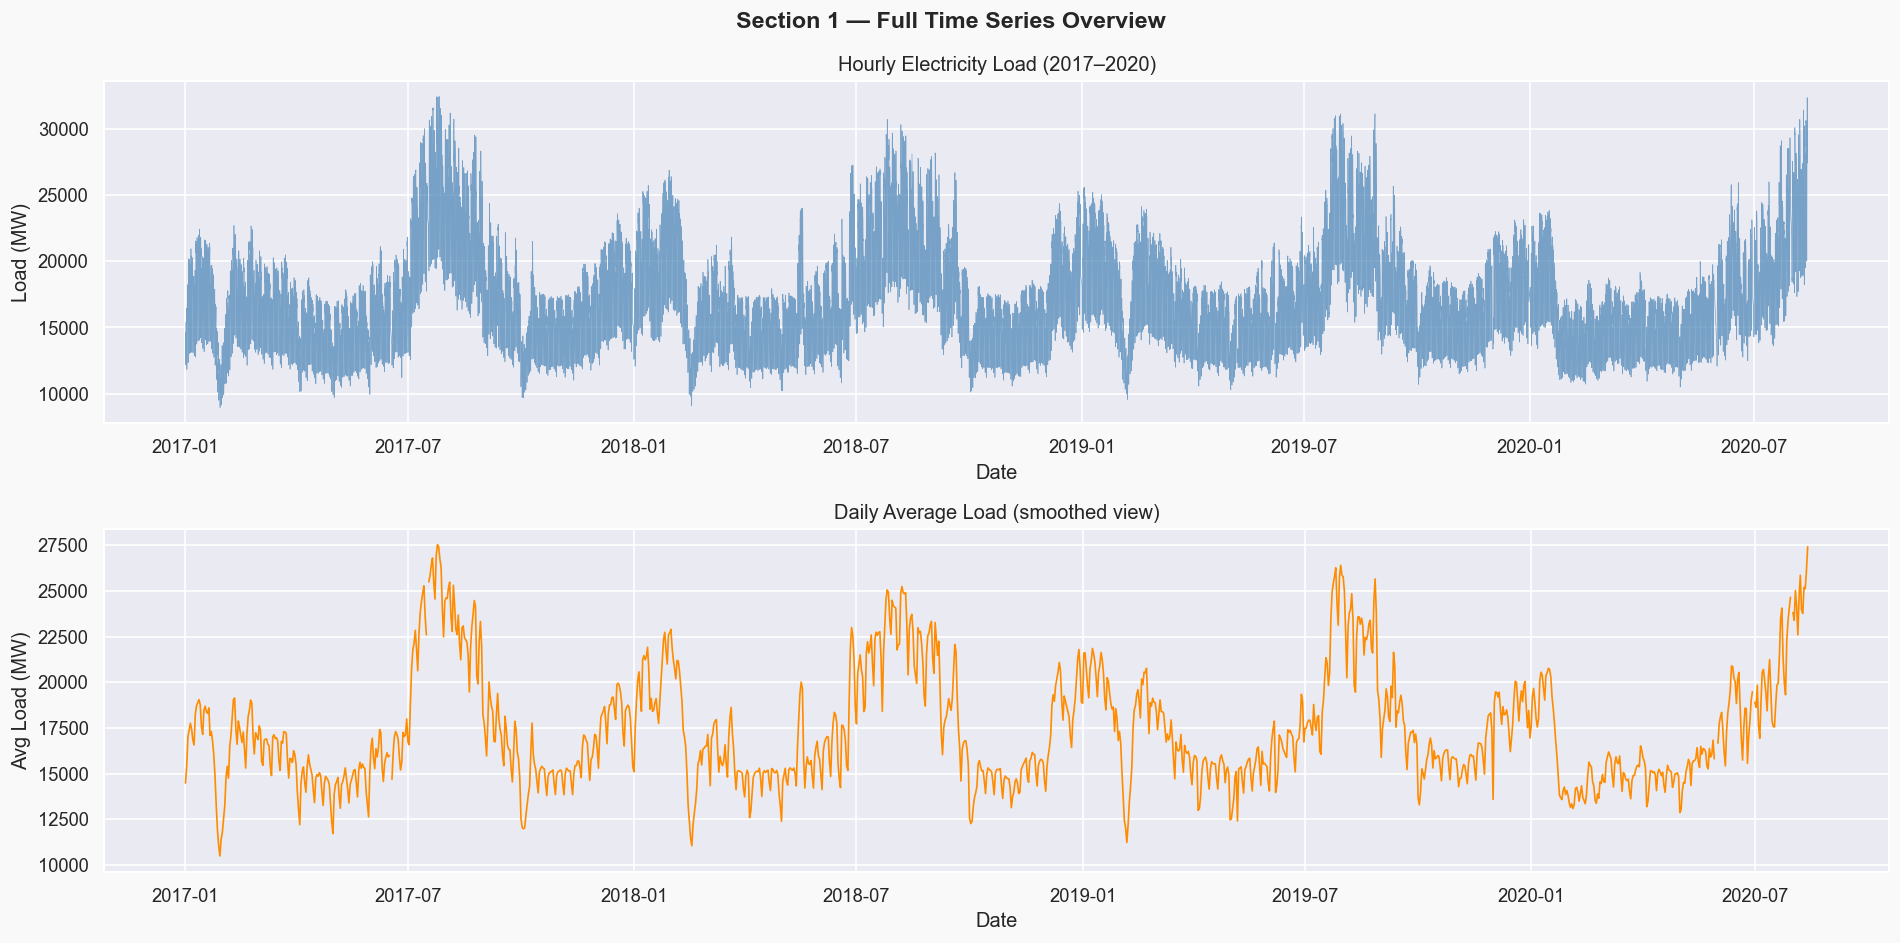

✅ Plot 1 saved: plot_1_timeseries.png


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 1 — TIME SERIES: Full load over 3.5 years
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)
fig.suptitle("Section 1 — Full Time Series Overview", fontsize=14, fontweight="bold")

# 1a. Raw hourly load
axes[0].plot(df["time"], df["load"], lw=0.4, color="steelblue", alpha=0.7)
axes[0].set_title("Hourly Electricity Load (2017–2020)")
axes[0].set_ylabel("Load (MW)")
axes[0].set_xlabel("Date")

# 1b. Daily average load (smoothed)
daily = df.resample("D", on="time")["load"].mean()
axes[1].plot(daily.index, daily.values, lw=1.0, color="darkorange")
axes[1].set_title("Daily Average Load (smoothed view)")
axes[1].set_ylabel("Avg Load (MW)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("shanhai_plot_1_timeseries.png")
plt.show()
print("✅ Plot 1 saved: plot_1_timeseries.png")


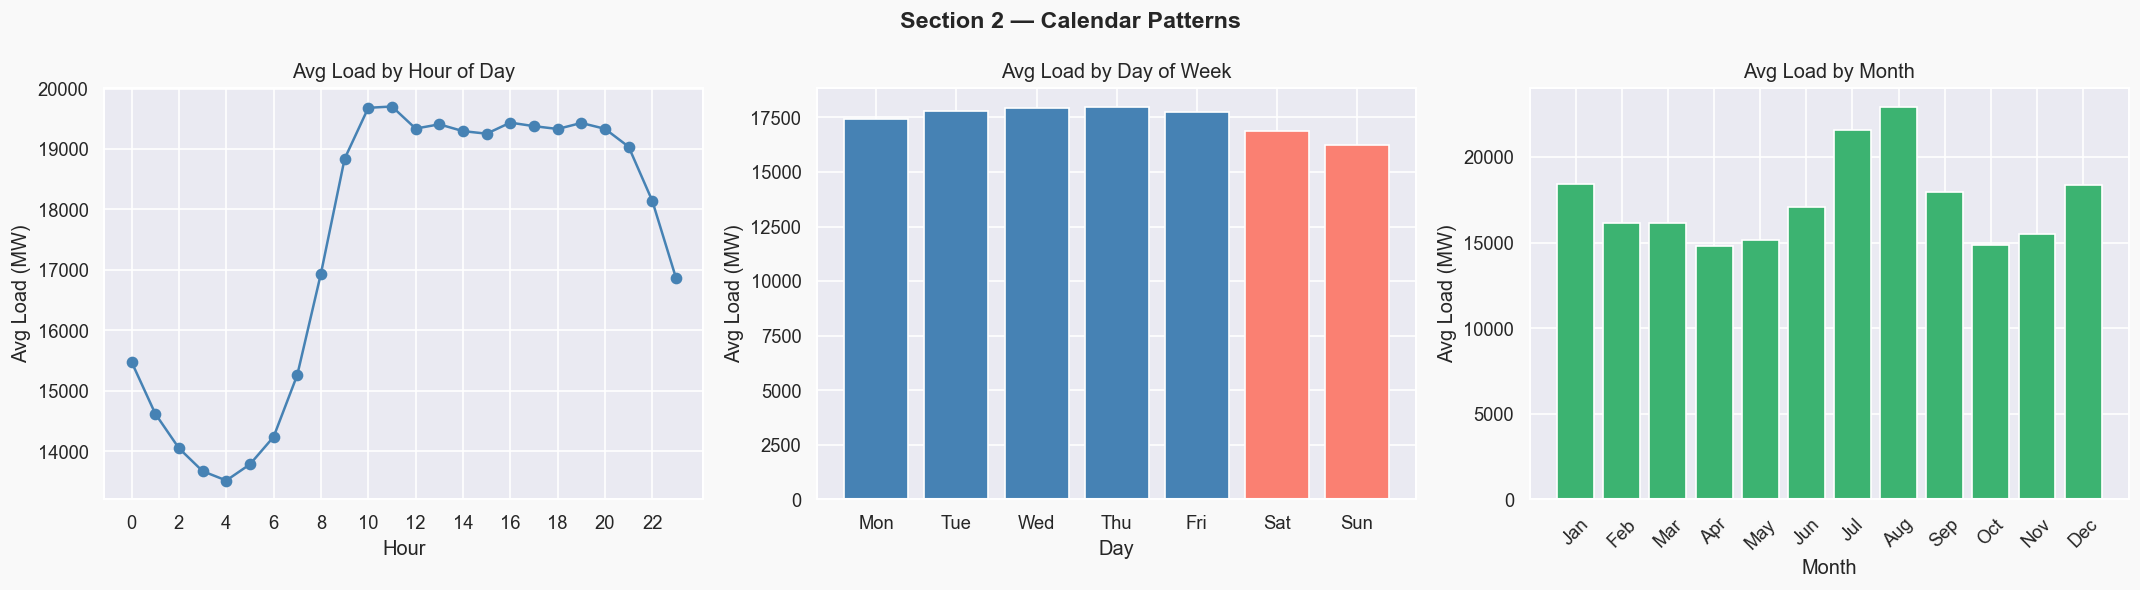

✅ Plot 2 saved: plot_2_calendar_patterns.png


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 2 — SEASONAL PATTERNS: Hour / Day / Month
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section 2 — Calendar Patterns", fontsize=14, fontweight="bold")

# 2a. Average load by hour
hourly_avg = df.groupby("hour")["load"].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker="o", color="steelblue")
axes[0].set_title("Avg Load by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Avg Load (MW)")
axes[0].set_xticks(range(0, 24, 2))

# 2b. Average load by day of week
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_avg = df.groupby("day_of_week")["load"].mean()
bars = axes[1].bar(dow_labels, dow_avg.values,
                   color=["steelblue"]*5 + ["salmon"]*2)
axes[1].set_title("Avg Load by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Avg Load (MW)")

# 2c. Average load by month
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
month_avg = df.groupby("month")["load"].mean()
axes[2].bar(month_labels, month_avg.values, color="mediumseagreen")
axes[2].set_title("Avg Load by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Avg Load (MW)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("plot_2_calendar_patterns.png")
plt.show()
print("✅ Plot 2 saved: plot_2_calendar_patterns.png")


C:\Users\khurs\AppData\Local\Temp\ipykernel_24144\2400754190.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day_type", y="load", palette=["steelblue", "salmon"], ax=axes[0])


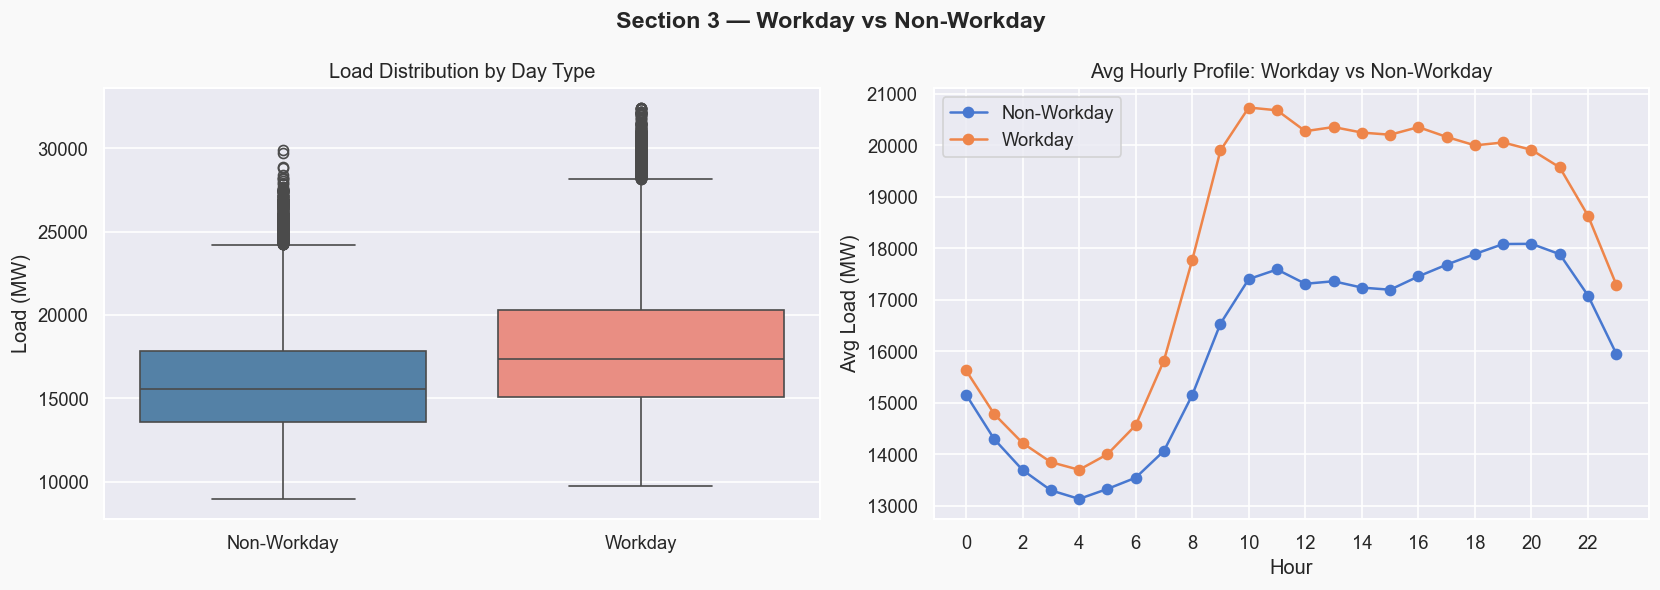

✅ Plot 3 saved: plot_3_workday_effect.png


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 3 — WORKDAY vs WEEKEND EFFECT
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Section 3 — Workday vs Non-Workday", fontsize=14, fontweight="bold")

# 3a. Box plot
df["day_type"] = df["is_workday"].map({1: "Workday", 0: "Non-Workday"})
sns.boxplot(data=df, x="day_type", y="load", palette=["steelblue", "salmon"], ax=axes[0])
axes[0].set_title("Load Distribution by Day Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Load (MW)")

# 3b. Hourly profile workday vs non-workday
for label, grp in df.groupby("day_type"):
    h = grp.groupby("hour")["load"].mean()
    axes[1].plot(h.index, h.values, marker="o", label=label)
axes[1].set_title("Avg Hourly Profile: Workday vs Non-Workday")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Avg Load (MW)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_3_workday_effect.png")
plt.show()
print("✅ Plot 3 saved: plot_3_workday_effect.png")


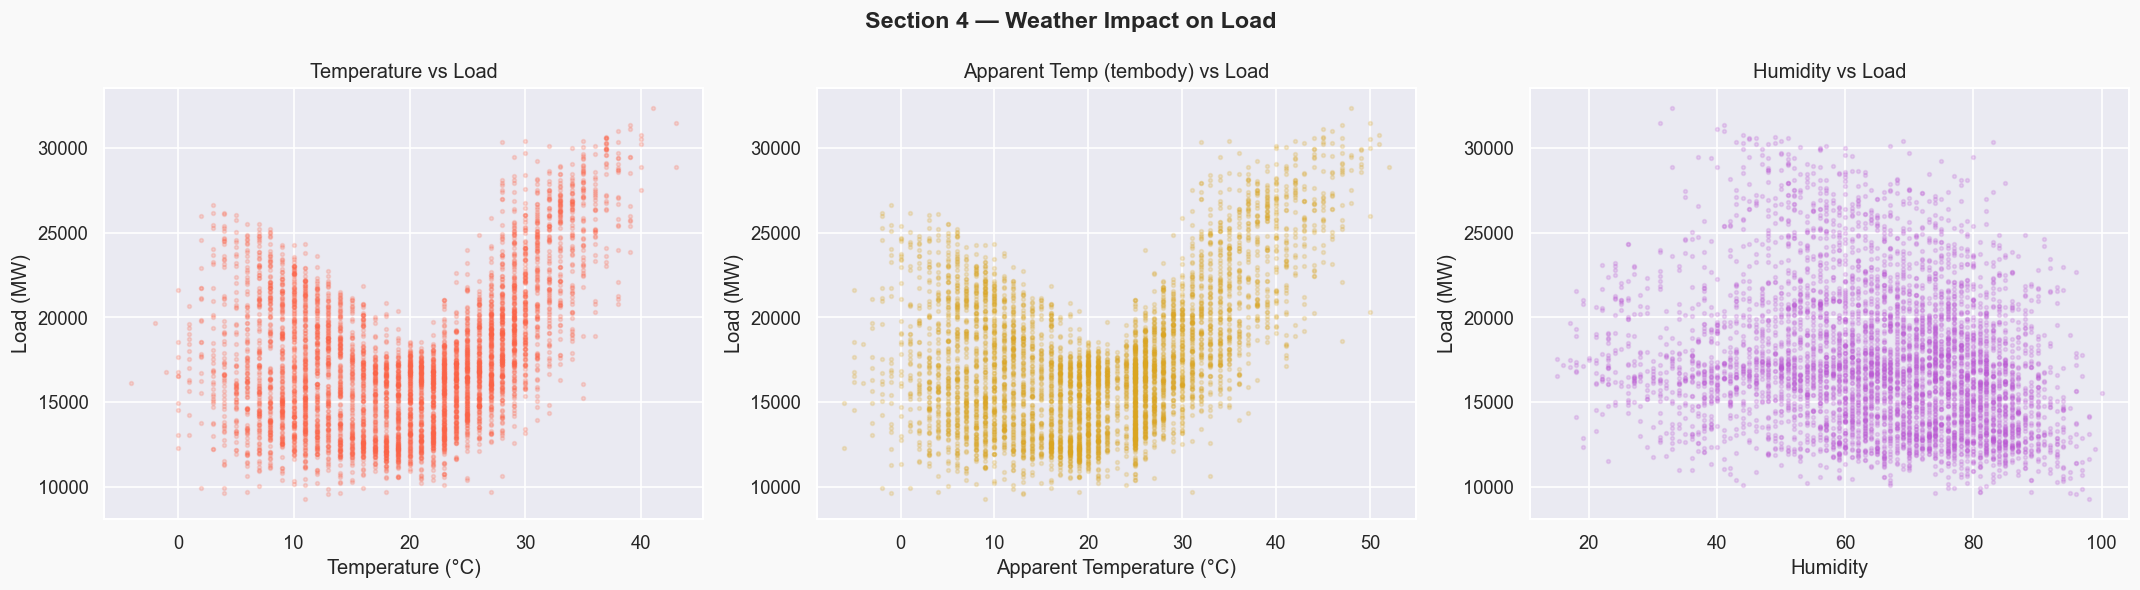

✅ Plot 4 saved: plot_4_weather_scatter.png


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 4 — WEATHER IMPACT ON LOAD
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section 4 — Weather Impact on Load", fontsize=14, fontweight="bold")

# 4a. Temperature vs Load scatter (sampled for speed)
sample = df.sample(5000, random_state=42)
axes[0].scatter(sample["tem"], sample["load"], alpha=0.2, s=5, color="tomato")
axes[0].set_title("Temperature vs Load")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Load (MW)")

# 4b. Apparent temperature (tembody) vs Load
axes[1].scatter(sample["tembody"], sample["load"], alpha=0.2, s=5, color="goldenrod")
axes[1].set_title("Apparent Temp (tembody) vs Load")
axes[1].set_xlabel("Apparent Temperature (°C)")
axes[1].set_ylabel("Load (MW)")

# 4c. Humidity vs Load
axes[2].scatter(sample["hum"], sample["load"], alpha=0.2, s=5, color="mediumorchid")
axes[2].set_title("Humidity vs Load")
axes[2].set_xlabel("Humidity")
axes[2].set_ylabel("Load (MW)")

plt.tight_layout()
plt.savefig("plot_4_weather_scatter.png")
plt.show()
print("✅ Plot 4 saved: plot_4_weather_scatter.png")

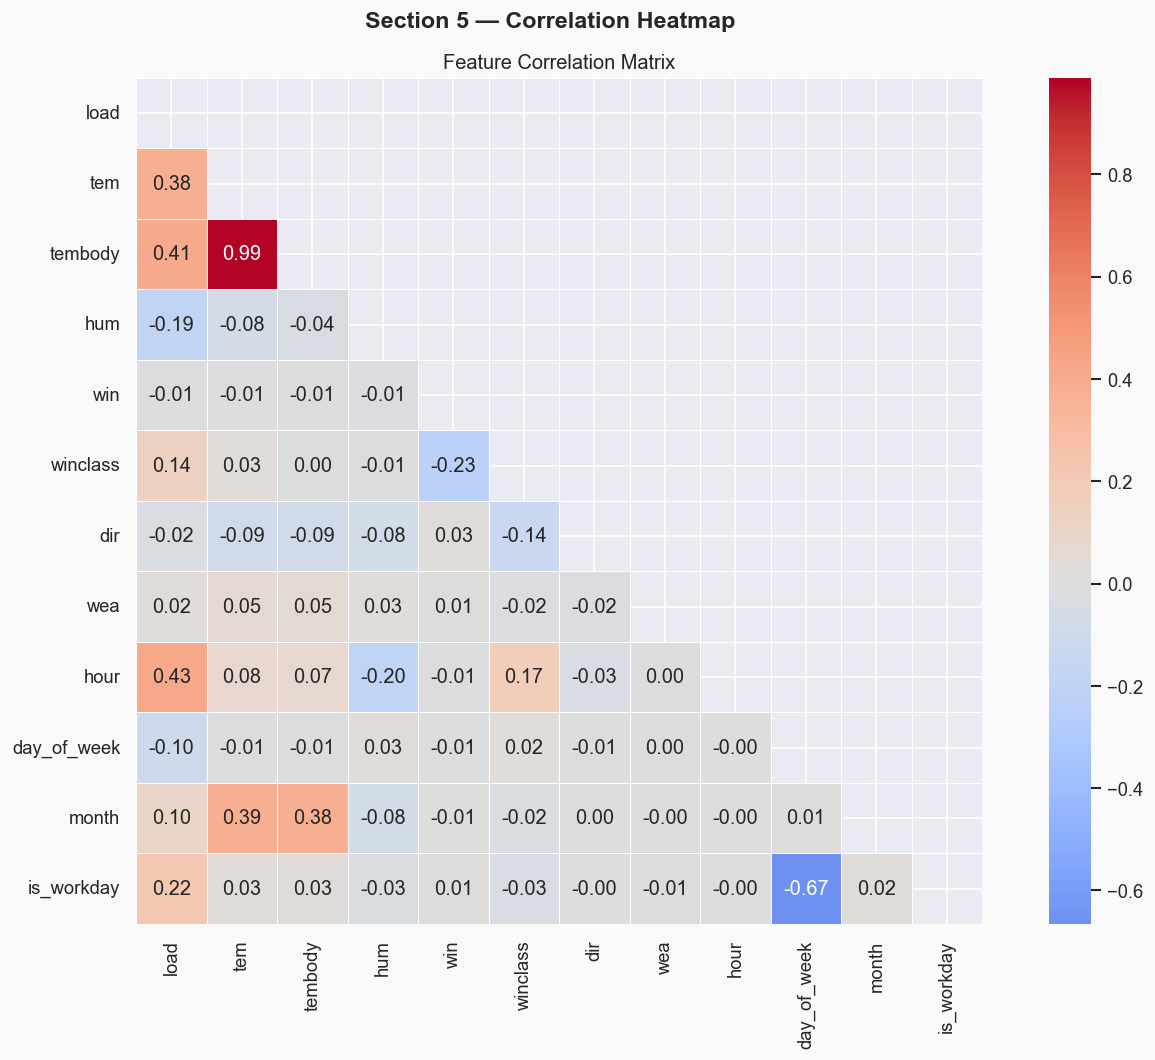

✅ Plot 5 saved: plot_5_correlation_heatmap.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 5 — CORRELATION HEATMAP
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle("Section 5 — Correlation Heatmap", fontsize=14, fontweight="bold")

numeric_cols = ["load", "tem", "tembody", "hum", "win", "winclass",
                "dir", "wea", "hour", "day_of_week", "month", "is_workday"]
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("plot_5_correlation_heatmap.png")
plt.show()
print("✅ Plot 5 saved: plot_5_correlation_heatmap.png")


C:\Users\khurs\AppData\Local\Temp\ipykernel_24144\3179149479.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(monthly_data, labels=month_labels)


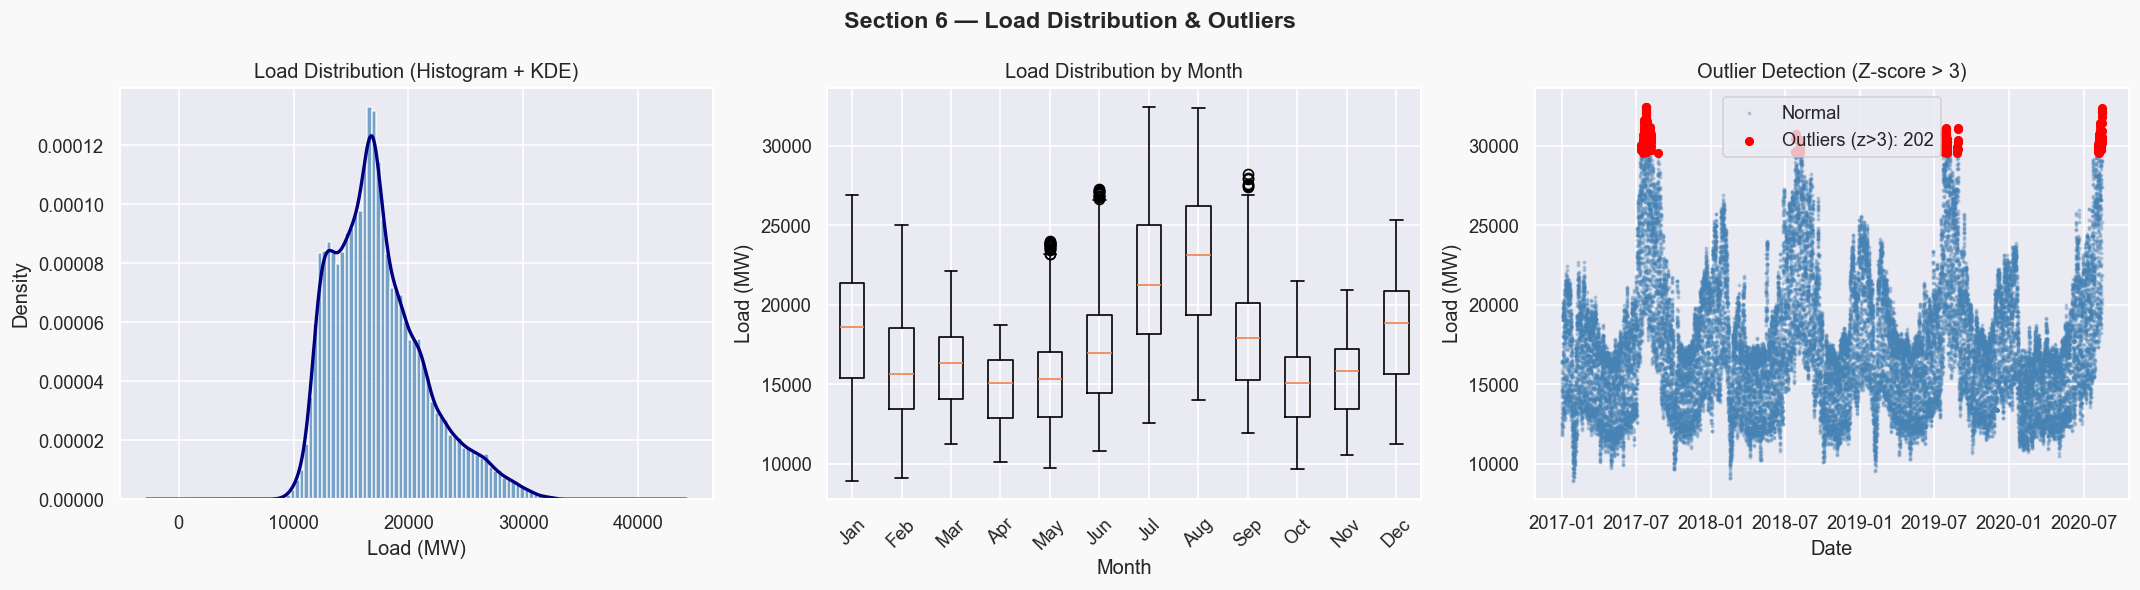

✅ Plot 6 saved: plot_6_distribution_outliers.png


In [9]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 6 — LOAD DISTRIBUTION & OUTLIERS
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section 6 — Load Distribution & Outliers", fontsize=14, fontweight="bold")

# 6a. Histogram + KDE
axes[0].hist(df["load"], bins=60, color="steelblue", edgecolor="white", density=True, alpha=0.7)
df["load"].plot.kde(ax=axes[0], color="navy", lw=2)
axes[0].set_title("Load Distribution (Histogram + KDE)")
axes[0].set_xlabel("Load (MW)")
axes[0].set_ylabel("Density")

# 6b. Boxplot by month
monthly_data = [df[df["month"] == m]["load"].values for m in range(1, 13)]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].boxplot(monthly_data, labels=month_labels)
axes[1].set_title("Load Distribution by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Load (MW)")
axes[1].tick_params(axis="x", rotation=45)

# 6c. Z-score outlier flagging
df["z_score"] = np.abs(stats.zscore(df["load"]))
outliers = df[df["z_score"] > 3]
axes[2].scatter(df["time"], df["load"], s=2, alpha=0.3, color="steelblue", label="Normal")
axes[2].scatter(outliers["time"], outliers["load"], s=20, color="red", zorder=5, label=f"Outliers (z>3): {len(outliers)}")
axes[2].set_title("Outlier Detection (Z-score > 3)")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Load (MW)")
axes[2].legend()

plt.tight_layout()
plt.savefig("plot_6_distribution_outliers.png")
plt.show()
print("✅ Plot 6 saved: plot_6_distribution_outliers.png")


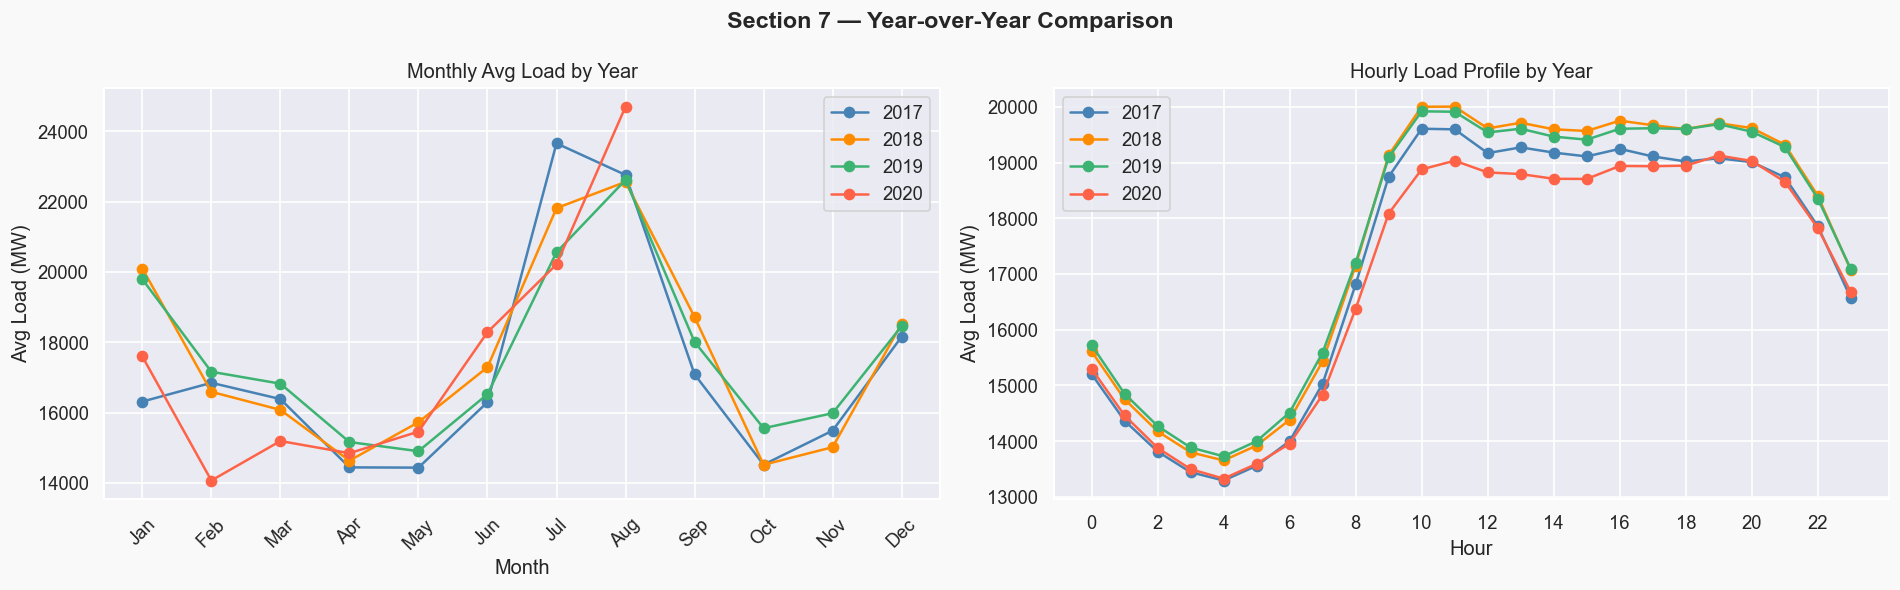

✅ Plot 7 saved: plot_7_year_comparison.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 7 — YEAR-OVER-YEAR COMPARISON (2017 vs 2018 vs 2019 vs 2020)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Section 7 — Year-over-Year Comparison", fontsize=14, fontweight="bold")

colors = {2017: "steelblue", 2018: "darkorange", 2019: "mediumseagreen", 2020: "tomato"}

# 7a. Monthly average per year
for yr, grp in df.groupby("year"):
    m_avg = grp.groupby("month")["load"].mean()
    axes[0].plot(m_avg.index, m_avg.values, marker="o",
                 label=str(yr), color=colors.get(yr, "gray"))
axes[0].set_title("Monthly Avg Load by Year")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Load (MW)")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)
axes[0].legend()

# 7b. Hourly profile per year
for yr, grp in df.groupby("year"):
    h_avg = grp.groupby("hour")["load"].mean()
    axes[1].plot(h_avg.index, h_avg.values, marker="o",
                 label=str(yr), color=colors.get(yr, "gray"))
axes[1].set_title("Hourly Load Profile by Year")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Avg Load (MW)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_7_year_comparison.png")
plt.show()
print("✅ Plot 7 saved: plot_7_year_comparison.png")


C:\Users\khurs\AppData\Local\Temp\ipykernel_24144\1705118975.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wc, x="winclass", y="load", palette="Blues", ax=axes[1],


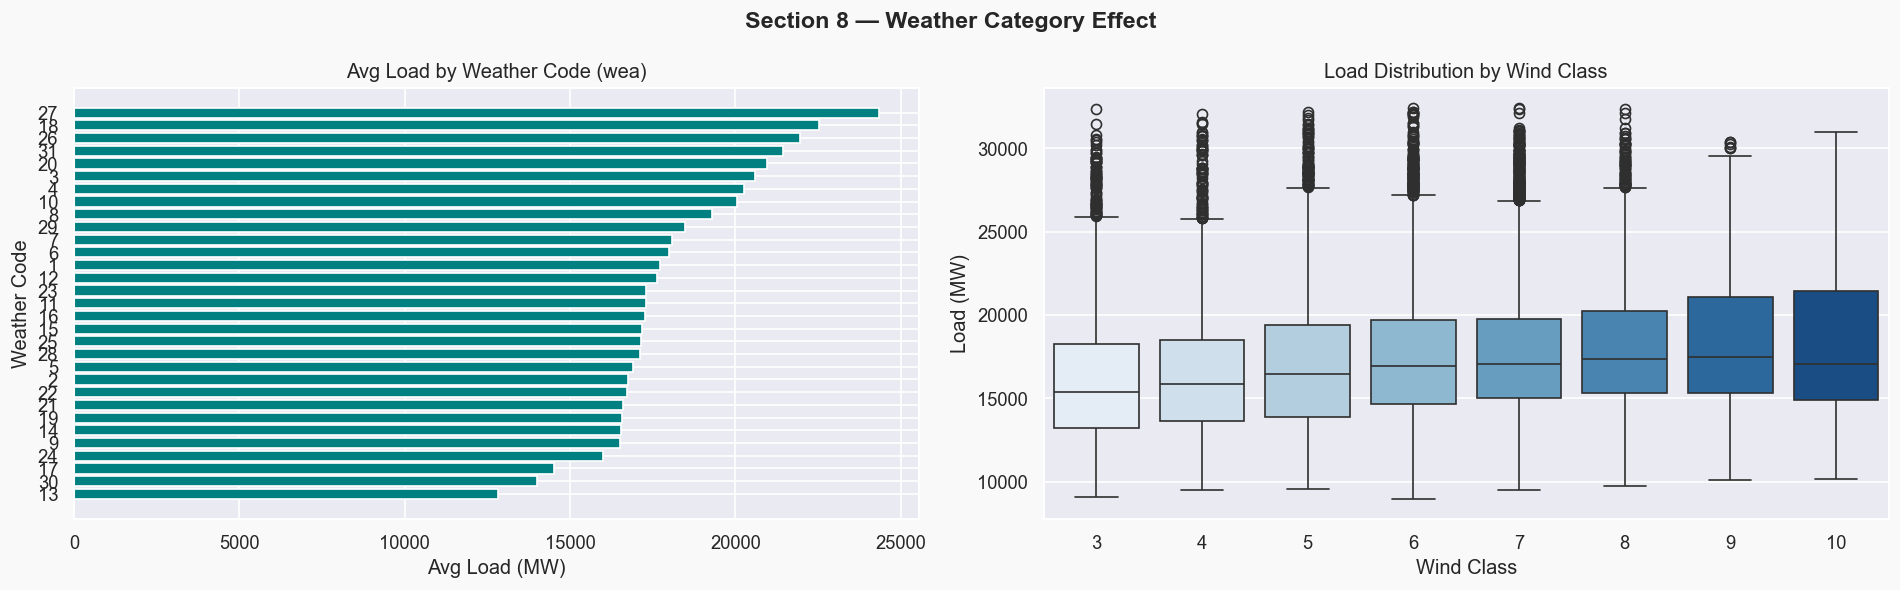

✅ Plot 8 saved: plot_8_weather_category.png


In [11]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 8 — WEATHER CATEGORY (wea) EFFECT ON LOAD
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Section 8 — Weather Category Effect", fontsize=14, fontweight="bold")

# 8a. Avg load per weather code
wea_avg = df.groupby("wea")["load"].mean().sort_values()
axes[0].barh(wea_avg.index.astype(str), wea_avg.values, color="teal")
axes[0].set_title("Avg Load by Weather Code (wea)")
axes[0].set_xlabel("Avg Load (MW)")
axes[0].set_ylabel("Weather Code")

# 8b. Wind class vs load box
top_wc = df["winclass"].value_counts().nlargest(8).index
df_wc = df[df["winclass"].isin(top_wc)]
sns.boxplot(data=df_wc, x="winclass", y="load", palette="Blues", ax=axes[1],
            order=sorted(top_wc))
axes[1].set_title("Load Distribution by Wind Class")
axes[1].set_xlabel("Wind Class")
axes[1].set_ylabel("Load (MW)")

plt.tight_layout()
plt.savefig("plot_8_weather_category.png")
plt.show()
print("✅ Plot 8 saved: plot_8_weather_category.png")


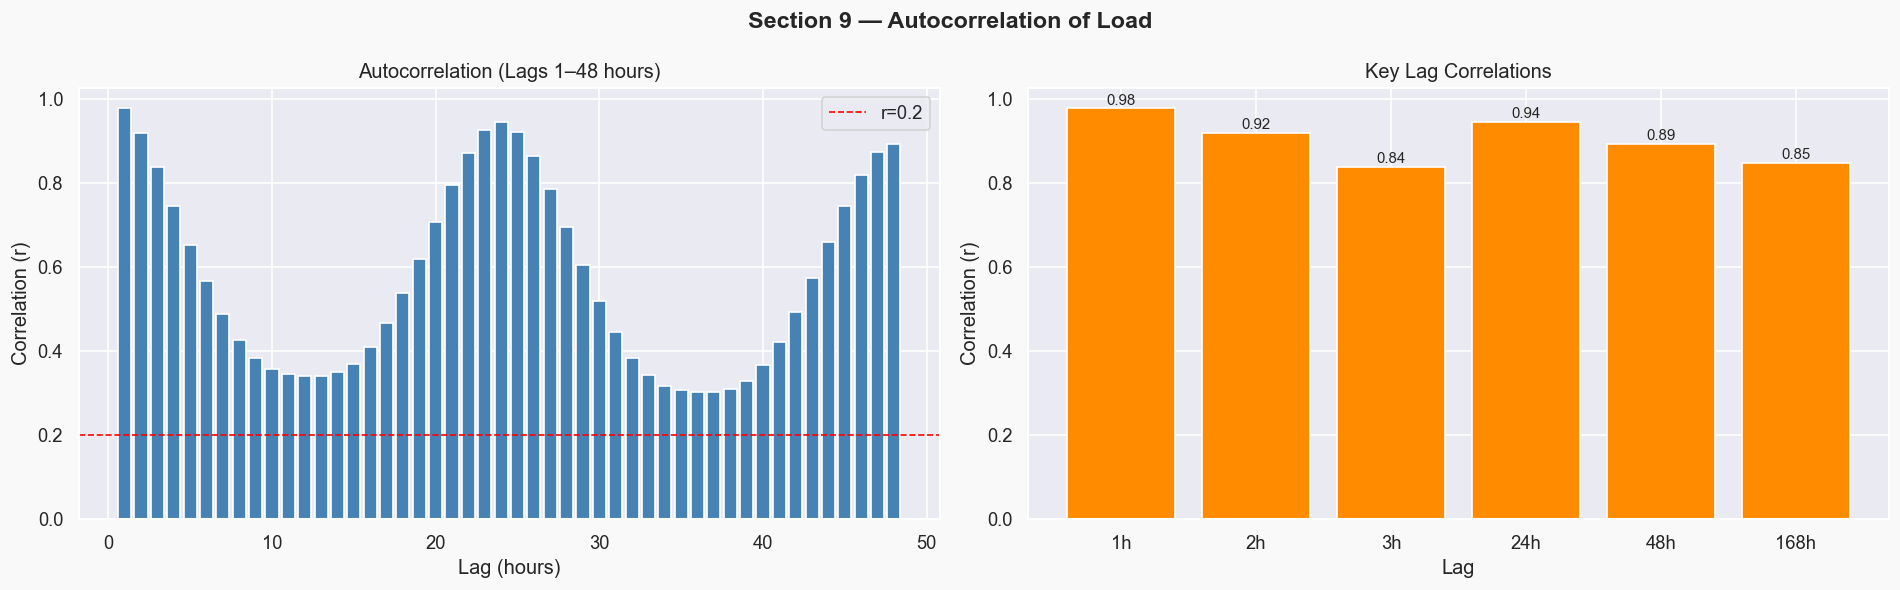

✅ Plot 9 saved: plot_9_autocorrelation.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 9 — LAG CORRELATION (autocorrelation)
# ══════════════════════════════════════════════════════════════════════════
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Section 9 — Autocorrelation of Load", fontsize=14, fontweight="bold")

# 9a. Lag correlations up to 48h
lags = range(1, 49)
acf_values = [df["load"].autocorr(lag=l) for l in lags]
axes[0].bar(lags, acf_values, color="steelblue")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axhline(0.2, color="red", lw=1, linestyle="--", label="r=0.2")
axes[0].set_title("Autocorrelation (Lags 1–48 hours)")
axes[0].set_xlabel("Lag (hours)")
axes[0].set_ylabel("Correlation (r)")
axes[0].legend()

# 9b. Same-hour yesterday, last week
special_lags = [1, 2, 3, 24, 48, 168]
special_acf = [df["load"].autocorr(lag=l) for l in special_lags]
axes[1].bar([str(l)+"h" for l in special_lags], special_acf, color="darkorange")
axes[1].set_title("Key Lag Correlations")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Correlation (r)")
for i, v in enumerate(special_acf):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("plot_9_autocorrelation.png")
plt.show()
print("✅ Plot 9 saved: plot_9_autocorrelation.png")


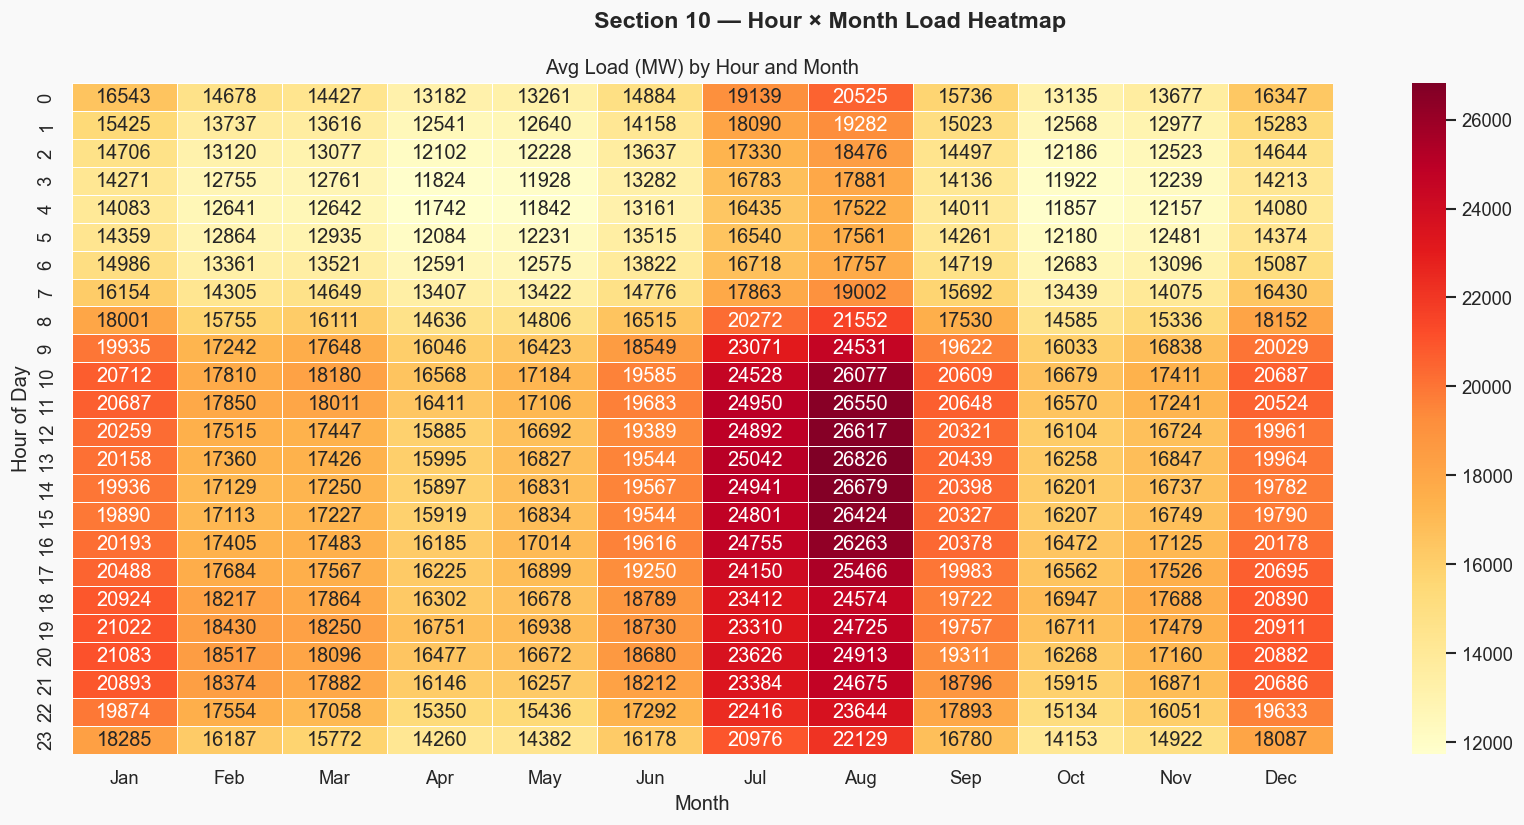

✅ Plot 10 saved: plot_10_hour_month_heatmap.png

🎉 All 10 EDA plots complete!


In [13]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 10 — HEATMAP: Hour × Month (average load)
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Section 10 — Hour × Month Load Heatmap", fontsize=14, fontweight="bold")

pivot = df.pivot_table(values="load", index="hour", columns="month", aggfunc="mean")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.3, ax=ax)
ax.set_title("Avg Load (MW) by Hour and Month")
ax.set_xlabel("Month")
ax.set_ylabel("Hour of Day")

plt.tight_layout()
plt.savefig("plot_10_hour_month_heatmap.png")
plt.show()
print("✅ Plot 10 saved: plot_10_hour_month_heatmap.png")

print("\n🎉 All 10 EDA plots complete!")

In [15]:
import pandas as pd

df = pd.read_csv("data\sh\shanghai.csv", parse_dates=["time"])
df

,time,wea,tem,hum,win,dir,winclass,tembody,year,month,day,hour,day_of_year,week_of_year,day_of_week,is_workday,load
0,2017-01-01 00:00:00,11,10,93,7,4,5,9,2017,1,1,0,1,52,6,0,14635.0
1,2017-01-01 01:00:00,11,10,93,7,4,5,8,2017,1,1,1,1,52,6,0,13644.8
2,2017-01-01 02:00:00,23,9,93,7,4,5,8,2017,1,1,2,1,52,6,0,12877.2
3,2017-01-01 03:00:00,23,9,93,7,1,5,7,2017,1,1,3,1,52,6,0,12530.0
4,2017-01-01 04:00:00,23,9,93,13,1,6,7,2017,1,1,4,1,52,6,0,12170.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31477,2020-08-13 19:00:00,29,31,69,6,3,7,38,2020,8,13,19,226,33,3,1,30185.3
31478,2020-08-13 20:00:00,29,28,82,11,1,8,32,2020,8,13,20,226,33,3,1,30546.6
31479,2020-08-13 21:00:00,23,28,83,11,1,8,32,2020,8,13,21,226,33,3,1,30343.3
31480,2020-08-13 22:00:00,29,28,83,11,1,8,32,2020,8,13,22,226,33,3,1,29021.8


In [17]:
import pandas as pd

# 1. Load the original Shanghai dataset
df = pd.read_csv("data\sh\shanghai.csv")

# 2. Convert the 'time' column to datetime format so Python can filter it accurately
df['time'] = pd.to_datetime(df['time'])

# 3. Filter for rows between January 1, 2017 and December 31, 2018 (inclusive)
start_date = "2017-01-01 00:00:00"
end_date = "2018-12-31 23:59:59"

filtered_df = df[(df['time'] >= start_date) & (df['time'] <= end_date)]

# 4. Save the filtered data to the new CSV file name
output_filename = "sh_glfn.csv"
filtered_df.to_csv(output_filename, index=False)

print(f"Success! Filtered data saved as '{output_filename}'.")
print(f"Original row count: {len(df)}")
print(f"New row count: {len(filtered_df)}")

Success! Filtered data saved as 'sh_glfn.csv'.
Original row count: 31482
New row count: 17426
